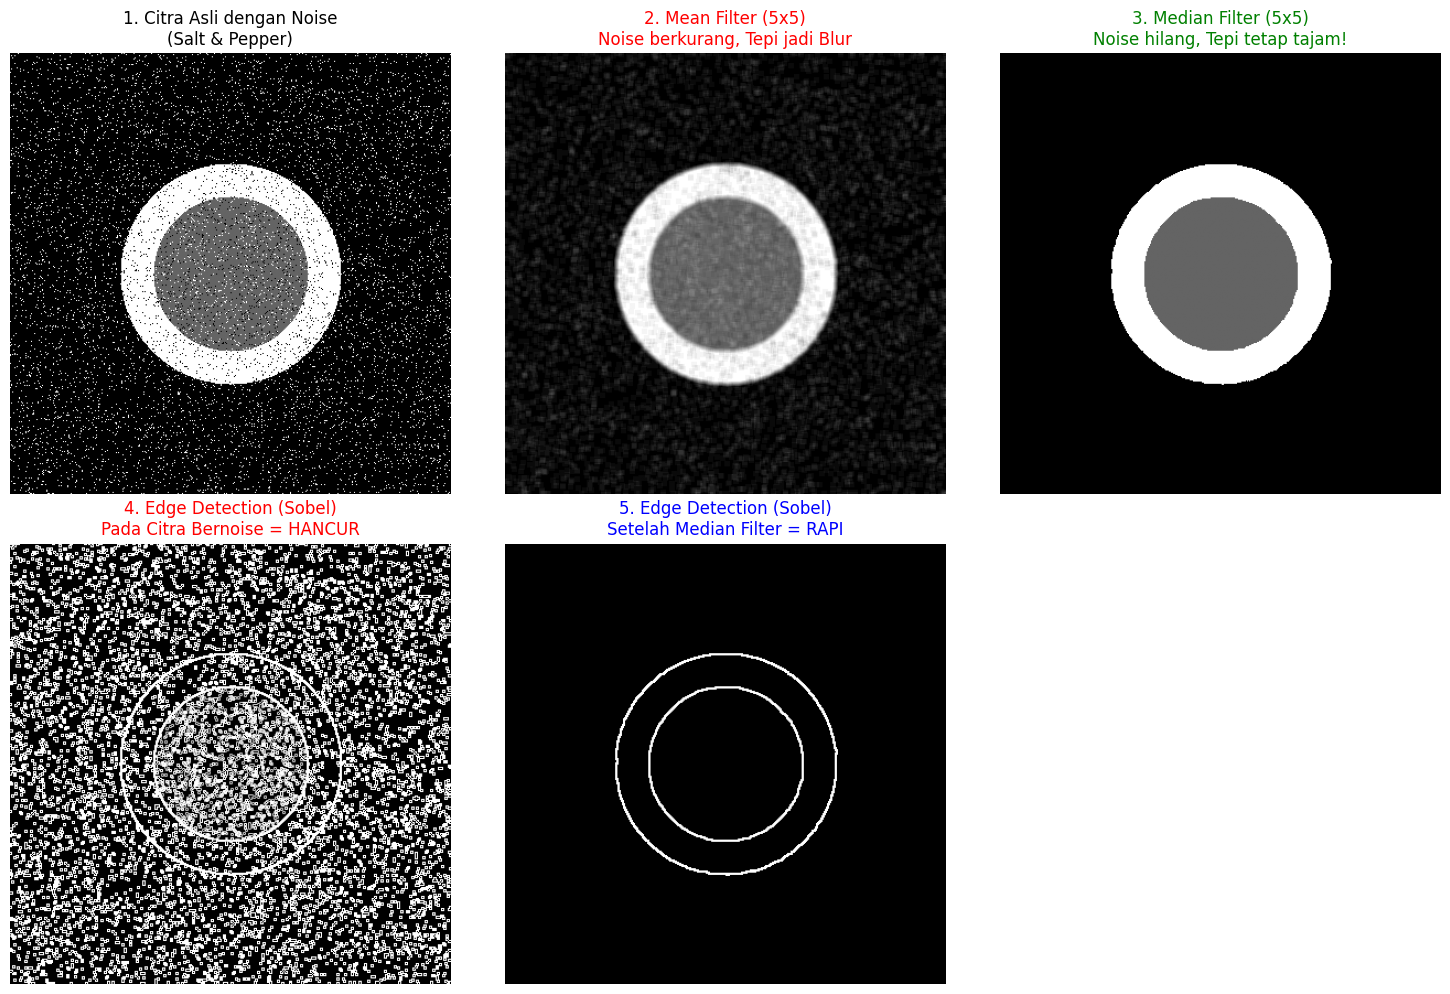

In [1]:
# ======================================================================
# DEMO PERTEMUAN 3: SPATIAL FILTERING & KONVOLUSI
# Skenario: Menghilangkan Noise pada Citra Medis / X-Ray
# ======================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# ----------------------------------------------------------------------
# 1. PERSIAPAN DATA: MENGUNDUH CITRA MEDIS (BRAIN MRI)
# ----------------------------------------------------------------------
url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/brainwash.jpg"
try:
    req = urllib.request.urlopen(url)
    arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
    img_asli = cv2.imdecode(arr, cv2.IMREAD_GRAYSCALE)
    img_asli = cv2.resize(img_asli, (400, 400))
except:
    # Fail-safe jika internet terputus
    img_asli = np.zeros((400, 400), dtype=np.uint8)
    cv2.circle(img_asli, (200, 200), 100, 255, -1)
    cv2.circle(img_asli, (200, 200), 70, 100, -1)

# ----------------------------------------------------------------------
# 2. SIMULASI KASUS: MENAMBAHKAN "SALT & PEPPER" NOISE
# ----------------------------------------------------------------------
img_noise = img_asli.copy()
prob = 0.05 # 5% piksel akan rusak
rnd = np.random.rand(img_noise.shape[0], img_noise.shape[1])
img_noise[rnd < prob] = 0       # Pepper (Bintik Hitam)
img_noise[rnd > 1 - prob] = 255 # Salt (Bintik Putih)

# ----------------------------------------------------------------------
# 3. MENCOBA BERBAGAI SPATIAL FILTER (3x3 KERNEL)
# ----------------------------------------------------------------------
# A. Mean Filter (Rata-rata biasa) - Akan membuat blur
img_mean = cv2.blur(img_noise, (5, 5))

# B. Gaussian Blur (Distribusi Normal) - Sedikit lebih natural dari Mean
img_gaussian = cv2.GaussianBlur(img_noise, (5, 5), 0)

# C. Median Filter (Non-Linear) - Sangat ampuh untuk Salt & Pepper
img_median = cv2.medianBlur(img_noise, 5)

# ----------------------------------------------------------------------
# 4. EDGE DETECTION (SOBEL) - Mencari Tepi Organ
# ----------------------------------------------------------------------
# Kita terapkan deteksi tepi pada citra yang MASIH bernoise vs yang SUDAH bersih (Median)
sobel_x = cv2.Sobel(img_noise, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_noise, cv2.CV_64F, 0, 1, ksize=3)
edge_noisy = cv2.magnitude(sobel_x, sobel_y)
edge_noisy = cv2.convertScaleAbs(edge_noisy)

sobel_x_clean = cv2.Sobel(img_median, cv2.CV_64F, 1, 0, ksize=3)
sobel_y_clean = cv2.Sobel(img_median, cv2.CV_64F, 0, 1, ksize=3)
edge_clean = cv2.magnitude(sobel_x_clean, sobel_y_clean)
edge_clean = cv2.convertScaleAbs(edge_clean)

# ----------------------------------------------------------------------
# 5. VISUALISASI HASIL
# ----------------------------------------------------------------------
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.title("1. Citra Asli dengan Noise\n(Salt & Pepper)", fontsize=12)
plt.imshow(img_noise, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title("2. Mean Filter (5x5)\nNoise berkurang, Tepi jadi Blur", color='red')
plt.imshow(img_mean, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title("3. Median Filter (5x5)\nNoise hilang, Tepi tetap tajam!", color='green')
plt.imshow(img_median, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.title("4. Edge Detection (Sobel)\nPada Citra Bernoise = HANCUR", color='red')
plt.imshow(edge_noisy, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.title("5. Edge Detection (Sobel)\nSetelah Median Filter = RAPI", color='blue')
plt.imshow(edge_clean, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()